# **Improting Needed Functions:**

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
#!pip install opencv-python
import pickle
import tensorflow as tf  # Import TensorFlow for deep learning
import os  # Import OS module for file operations
import string
import numpy as np
import pandas as pd
from PIL import Image
from keras.models import Model, load_model         # Import Model class from Keras
from keras.layers import Add
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16, VGG19  # Import pre-trained models
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg  # Preprocessing function for VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array  # Functions for image loading and processing
from tensorflow.keras.preprocessing.text import Tokenizer  # Tokenizer for text processing
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Function for padding sequences
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout  # Import required layers
from tensorflow.keras.utils import to_categorical  # Function for one-hot encoding
from pickle import dump, load  # Import pickle for saving/loading data
import string  # Import string module for text processing
import matplotlib.pyplot as plt  # Import Matplotlib for visualization
import cv2

# **Definig a Function to load captions from the dataset:**

In [2]:
def load_captions(filepath):
    captions = {}  # Dictionary to store captions
    with open(filepath, 'r') as file:  # Open file in read mode
        for line in file:  # Iterate through each line
            line = line.strip()  # Remove leading/trailing spaces
            if not line:  # Skip empty lines
                continue
            image_id, caption = line.split('\t')  # Split line into image ID and caption
            image_id = image_id.split('#')[0]  # Extract image filename
            caption = caption.lower().translate(str.maketrans('', '', string.punctuation))  # Convert caption to lowercase and remove punctuation
            captions.setdefault(image_id, []).append(caption)  # Store captions for each image
    return captions  # Return dictionary of captions

# **Defining a Function to extract features using a pre-trained model:**


In [3]:
def extract_features(model, preprocess_fn, directory):
    features = {}  # Dictionary to store image features
    for img_name in os.listdir(directory):  # Iterate through image files
        if img_name.lower().endswith(('jpg', 'jpeg', 'png')):  # Check valid image formats
            img_path = os.path.join(directory, img_name)  # Construct image path
            image = load_img(img_path, target_size=(224, 224))  # Load and resize image
            image = img_to_array(image)  # Convert image to array
            image = np.expand_dims(image, axis=0)  # Expand dimensions for model input
            image = preprocess_fn(image)  # Preprocess image for the model
            feature = model.predict(image, verbose=0)  # Extract features using model
            features[img_name] = feature.flatten()  # Flatten feature vector and store
    return features  # Return extracted features

# **Loading Pre-trained Models:**

In [4]:
# Load pre-trained VGG16 model
vgg16_model = VGG16(weights='imagenet')  # Load VGG16 with pre-trained weights
vgg16_model = Model(inputs=vgg16_model.input, outputs=vgg16_model.layers[-2].output)  # Modify model to output feature vectors

# Load pre-trained VGG19 model
#vgg19_model = VGG19(weights='imagenet')  # Load VGG19 with pre-trained weights
#vgg19_model = Model(inputs=vgg19_model.input, outputs=vgg19_model.layers[-2].output)  # Modify model to output feature vectors

# **Defining Dataset Path, Extracting and Saving Images Features:**

In [5]:
# Define dataset path
dataset_path = "E:\Courses\Software\AI\Array\Final Project\Flickr8k_Dataset\Flicker8k_Dataset"  # Path to images

#Extract features using different models
print("Extracting VGG16 features...")  # Print status
#vgg16_features = extract_features(vgg16_model, preprocess_vgg, dataset_path)  # Extract features using VGG16



# Save extracted features
#dump(vgg16_features, open("vgg16_features.pkl", "wb"))  # Save VGG16 features



#download extracted features
#files.download("vgg16_features.pkl")  # Download VGG16 features


Extracting VGG16 features...


# **Loading and Tokenizing Captions:**

In [6]:
# Load captions
dataset_captions = load_captions("E:\Courses\Software\AI\Array\Final Project\Flickr8k_text\Flickr8k.token.txt")  # Load captions from dataset

# Tokenize captions
tokenizer = Tokenizer()  # Initialize tokenizer
tokenizer.fit_on_texts([caption for captions in dataset_captions.values() for caption in captions])  # Fit tokenizer to captions
vocab_size = len(tokenizer.word_index) + 1  # Define vocabulary size
max_length = max(len(caption.split()) for captions in dataset_captions.values() for caption in captions)  # Determine max caption length

# **Loading precomputed features:**


In [7]:
# Specify the file path (change this to your desired location)
file_path = r"E:\Courses\Software\AI\Array\Final Project\vgg16_features.pkl"

# Save the file
#with open(file_path, "wb") as file:
    #pickle.dump(vgg16_features, file)

#print("Pickle file saved successfully!")

with open("vgg16_features.pkl", "rb") as f:
    vgg16_features = pickle.load(f)
features_dict = vgg16_features   # or use vgg19_features    
print("Available feature keys:", list(features_dict.keys())[:10])  # Print first 10 keys


Available feature keys: ['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg', '1007129816_e794419615.jpg', '1007320043_627395c3d8.jpg', '1009434119_febe49276a.jpg', '1012212859_01547e3f17.jpg', '1015118661_980735411b.jpg', '1015584366_dfcec3c85a.jpg']


# **Preparing Training Data:**


In [8]:
def create_sequences(tokenizer, max_length, dataset_captions, features_dict, vocab_size):
    X1, X2, y = [], [], []

    for img_id, captions in dataset_captions.items():
        if img_id not in features_dict:
            print(f"Skipping {img_id}, feature not found!")  # Debug missing features
            continue

        feature = features_dict[img_id]  # Load precomputed feature
        print(f"Processing {img_id}, Feature Shape: {feature.shape}")  # Debugging step

        for caption in captions:
            seq = tokenizer.texts_to_sequences([caption])[0]
            for i in range(1, len(seq)):
                in_seq, out_word = seq[:i], seq[i]

                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]  # Pad sequence
                out_word = to_categorical([out_word], num_classes=vocab_size)[0]  # One-hot encode

                X1.append(feature)  # Image feature
                X2.append(in_seq)   # Text input
                y.append(out_word)  # Next word

    print(f"Total Samples: {len(X1)}")  # Debugging step
    return np.array(X1), np.array(X2), np.array(y)

# Generate Training Data
X1_train, X2_train, y_train = create_sequences(tokenizer, max_length, dataset_captions, features_dict, vocab_size)

# Final Check
print("Final X1 Shape:", X1_train.shape)
print("Final X2 Shape:", X2_train.shape)
print("Final y Shape:", y_train.shape)

Processing 1000268201_693b08cb0e.jpg, Feature Shape: (4096,)
Processing 1001773457_577c3a7d70.jpg, Feature Shape: (4096,)
Processing 1002674143_1b742ab4b8.jpg, Feature Shape: (4096,)
Processing 1003163366_44323f5815.jpg, Feature Shape: (4096,)
Processing 1007129816_e794419615.jpg, Feature Shape: (4096,)
Processing 1007320043_627395c3d8.jpg, Feature Shape: (4096,)
Processing 1009434119_febe49276a.jpg, Feature Shape: (4096,)
Processing 1012212859_01547e3f17.jpg, Feature Shape: (4096,)
Processing 1015118661_980735411b.jpg, Feature Shape: (4096,)
Processing 1015584366_dfcec3c85a.jpg, Feature Shape: (4096,)
Processing 101654506_8eb26cfb60.jpg, Feature Shape: (4096,)
Processing 101669240_b2d3e7f17b.jpg, Feature Shape: (4096,)
Processing 1016887272_03199f49c4.jpg, Feature Shape: (4096,)
Processing 1019077836_6fc9b15408.jpg, Feature Shape: (4096,)
Processing 1019604187_d087bf9a5f.jpg, Feature Shape: (4096,)
Processing 1020651753_06077ec457.jpg, Feature Shape: (4096,)
Processing 1022454332_6af2

# **Building a Captioning Model:**

In [9]:
# Function to build captioning model
def build_model(vocab_size, max_length):
    inputs = Input(shape=(4096,))  # Input layer for image features
    x = Dense(512, activation='relu')(inputs)  # Dense layer for feature transformation
    x = Dropout(0.2)(x)  # Dropout layer for regularization

    text_input = Input(shape=(max_length,))  # Input layer for text sequences
    embedding = Embedding(vocab_size, 512, mask_zero=True)(text_input)  # Embedding layer
    lstm = LSTM(512, return_sequences=False)(embedding)  # LSTM layer for sequence processing

    decoder = tf.keras.layers.add([x, lstm])  # Merge image and text features
    decoder = Dense(512, activation='relu')(decoder)  # Dense layer
    outputs = Dense(vocab_size, activation='softmax')(decoder)  # Output layer

    model = Model(inputs=[inputs, text_input], outputs=outputs)  # Define model
    optimizer = Adam(learning_rate=0.0001)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer)  # Compile model
    return model  # Return compiled model

# Build model
caption_model = build_model(vocab_size, max_length)  # Create captioning model
# Train the model
caption_model.fit([X1_train, X2_train], y_train, epochs=2, batch_size=64, verbose=1)

caption_model.summary()  # Print model summary

Epoch 1/2


C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_23', 'keras_tensor_26']. Received: the structure of inputs=('*', '*')
  warnings.warn(


6189/6189 ━━━━━━━━━━━━━━━━━━━━ 1871s 292ms/step - loss: 5.1756
Epoch 2/2
6189/6189 ━━━━━━━━━━━━━━━━━━━━ 1794s 290ms/step - loss: 3.6259


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  2,097,664 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 36, 512)   │  4,520,448 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 36)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 512)       │  2,099,200 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dropout[0][0],    │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8829)      │  4,529,277 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,527,737 (154.60 MB)

 Trainable params: 13,509,245 (51.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,018,492 (103.07 MB)

# **Defining a Function to generate captions:**


In [16]:
from collections import OrderedDict

def remove_repeated_words(caption):
    words = caption.split()
    unique_words = list(OrderedDict.fromkeys(words))  # Remove duplicates while maintaining order
    return ' '.join(unique_words)


def generate_caption(model, tokenizer, photo, max_length):
    in_text = 'startseq'  # Start sequence token
    repeated_words = set()  # Set to track words used
    for _ in range(max_length):  # Generate words up to max_length
        sequence = tokenizer.texts_to_sequences([in_text])[0]  # Convert text to sequence
        sequence = pad_sequences([sequence], maxlen=max_length)  # Pad sequence
        yhat = model.predict([photo, sequence], verbose=0)  # Predict next word
        yhat = np.argmax(yhat)  # Get highest probability word
        word = tokenizer.index_word.get(yhat, None)  # Convert index to word
        if word is None:
            break
        in_text += ' ' + word  # Append word to sequence
        if word == 'endseq':  # Stop if end token is reached
            break
    return in_text.replace('startseq', '').replace('endseq', '').strip()  # Return and Clean up the output generated caption

# **Defining a Function to preprocess and extract features from a new image:**

In [17]:

def extract_feature_from_image(model, preprocess_fn, image_path):
    image = load_img(image_path, target_size=(224, 224))  # Resize image for VGG models
    image = img_to_array(image)  # Convert to array
    image = np.expand_dims(image, axis=0)  # Expand dimensions
    image = preprocess_fn(image)  # Preprocess for the model
    feature = model.predict(image, verbose=0)  # Extract feature
    return feature.flatten().reshape(1, -1)  # Return as input format

# **Testing the Caption Generator:**

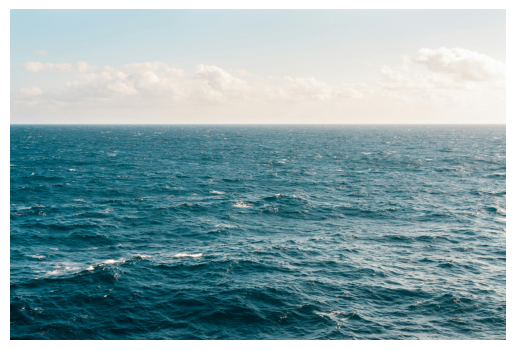


Generated Caption: surfers in the ocean is


In [41]:
# Function to test the caption generator
def test_caption_generator(image_path, model, vgg_extractor,  preprocess_vgg,  tokenizer, max_length):
    feature = extract_feature_from_image(vgg_extractor,  preprocess_vgg,  image_path)         # Extract features using VGG 16
    caption = generate_caption(model, tokenizer, feature, max_length)                       # Generate caption
    caption = caption.replace('startseq', '').strip()                                         # Remove 'startseq' from the beginning of the generated caption
    caption = caption.replace('endseq', '').strip()                                           # Remove 'endseq' as well if it appears at the end
    caption = remove_repeated_words(caption)                                                  # Remove repeated words
    img = Image.open(image_path)                                                              # Display the image
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    print("\nGenerated Caption:", caption)

# Choose an image for testing
#test_image_path = "E:/Courses/Software/AI/Array/Final Project/Flickr8k_Dataset/Flicker8k_Dataset/2251747182_6b67a3ab8b.jpg"  # Change this path to your test image
test_image_path = "C:/Users/moham/Desktop/pexels-kellie-churchman-371878-1001682.jpg"

# Test caption generator
test_caption_generator(test_image_path, caption_model, vgg16_model,  preprocess_vgg,  tokenizer, max_length=5)
#test_caption_generator(test_image_path, caption_model, vgg19_model,  preprocess_vgg,  tokenizer, max_length)

# **Saving Moddel Parameters for Later Streamlit Deployment:**

In [42]:
caption_model.save("caption_model.h5")

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

with open("max_length.pkl", "wb") as file:
    pickle.dump(max_length, file)



# **Creating a Streamlit App:**

In [43]:
#!pip install streamlit tensorflow numpy pillow

import streamlit as st
import pickle
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# Load the saved model and tokenizer
@st.cache_resource
def load_caption_model():
    return tf.keras.models.load_model("caption_model.h5")

@st.cache_data
def load_tokenizer():
    with open("tokenizer.pkl", "rb") as file:
        return pickle.load(file)

@st.cache_data
def load_max_length():
    with open("max_length.pkl", "rb") as file:
        return pickle.load(file)

# Load VGG16 model for feature extraction
@st.cache_resource
def load_vgg16():
    model = VGG16(weights="imagenet")
    return tf.keras.models.Model(inputs=model.input, outputs=model.layers[-2].output)

# Function to extract features from an image
def extract_features(image, model):
    image = image.resize((224, 224))
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    feature = model.predict(image, verbose=0)
    return feature.flatten().reshape(1, -1)

# Function to generate a caption
def generate_caption(model, tokenizer, photo, max_length):
    in_text = "startseq"
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat, None)
        if word is None:
            break
        in_text += " " + word
        if word == "endseq":
            break
    return in_text.replace("startseq", "").replace("endseq", "").strip()

# Streamlit UI
st.title("Image Caption Generator")

uploaded_image = st.file_uploader("Upload an image", type=["jpg", "jpeg", "png"])
if uploaded_image is not None:
    image = Image.open(uploaded_image)
    st.image(image, caption="Uploaded Image", use_column_width=True)

    if st.button("Generate Caption"):
        st.write("Processing...")

        # Load resources
        caption_model = load_caption_model()
        tokenizer = load_tokenizer()
        max_length = load_max_length()
        vgg_model = load_vgg16()

        # Extract image features
        feature = extract_features(image, vgg_model)

        # Generate and display caption
        caption = generate_caption(caption_model, tokenizer, feature, max_length=5)
        st.subheader("Generated Caption:")
        st.write(caption)

2025-02-09 13:55:10.505 No runtime found, using MemoryCacheStorageManager
2025-02-09 13:55:10.508 No runtime found, using MemoryCacheStorageManager
2025-02-09 13:55:10.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-02-09 13:55:10.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-02-09 13:55:10.512 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-02-09 13:55:10.513 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-02-09 13:55:10.514 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-02-09 13:55:10.515 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-02-09 13:55:10.516 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

# **Running The Created Streamlit App:**

In [35]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)